<a href="https://colab.research.google.com/github/DHAARANI-GANESHTHANGAM/Everyday_Object_Detection/blob/main/05_train_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Goal: teach YOLOv8n your 6 classes using the training images, then score it the same way as v0.

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -q ultralytics
import sys
sys.path.append("/content/drive/MyDrive/Everyday_Object_Detection")
from eval_utils import *
import eval_utils
print("Ready:", PROJECT)


Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 10.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ready: /content/drive/MyDrive/Everyday_Object_Detection


 Copy the data to Colab's local disk

This fixes the slow-Drive problem. Without it, every epoch reads all 2,315 images from Drive, which could make training take hours.

The images are the same ones, just read from a faster location, so v1's scores stay directly comparable with v0.

In [2]:
import yaml, os

!cp -r "{PROJECT}/data" /content/data

cfg = yaml.safe_load(open("/content/data/dataset.yaml"))
cfg["path"] = "/content/data"
yaml.safe_dump(cfg, open("/content/data/dataset.yaml", "w"))

eval_utils.DATA = "/content/data/dataset.yaml"   # train + evaluate from the local copy
print(open(eval_utils.DATA).read())
!ls /content/data/images/train | wc -l
!ls /content/data/images/val | wc -l

names:
  0: Glasses
  1: Sunglasses
  2: Headphones
  3: Watch
  4: Pen
  5: Hat
path: /content/data
train: ./images/train/
val: ./images/val/

2315
349


Training V1:

What to watch while it runs:

Each epoch prints a box_loss/cls_loss line and then a validation line with mAP50 and mAP50-95. The losses should go down and the mAP should go up over the epochs.

In [3]:
best_v1 = train_version("v1", base="yolov8n.pt", epochs=30)

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/dataset.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1, nbs=64, nms=None, opset=None, optimize=False, o

**Evaluate and gate**

In [4]:
evaluate_and_log(best_v1, "v1", "Fine-tune YOLOv8n, 30 epochs, imgsz 640")
regression_check("v1")

Ultralytics 8.4.162 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,818 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3790.8±1166.2 MB/s, size: 368.0 KB)
val: Scanning /content/data/labels/val.cache... 349 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 349/349 81.3Mit/s 0.0s
val: /content/data/images/val/0447d80c8ce6fa36.jpg: 1 duplicate labels removed
val: /content/data/images/val/06a4b34d1e9c7599.jpg: 1 duplicate labels removed
val: /content/data/images/val/06fc752c870a31fb.jpg: 1 duplicate labels removed
val: /content/data/images/val/0765e6dc62dcca57.jpg: 2 duplicate labels removed
val: /content/data/images/val/0908dd33cf950266.jpg: 1 duplicate labels removed
val: /content/data/images/val/0a8fc50cd3e3df1a.jpg: 1 duplicate labels removed
val: /content/data/images/val/149a74e86e8161a5.jpg: 1 duplicate labels removed
val: /content/data/images/val/1e0a44b7b3cb1d5f.jpg: 1 duplicate labels

('PASS', [])

**Comparing with Baseline**

,mAP50,mAP50_95,precision,recall,FPS
version,,,,,
v0,0.3862,0.2777,0.3212,0.5686,86.7
v1,0.6755,0.4366,0.7459,0.6113,117.5


version,v0,v1
mAP50_95,0.2777,0.4366
AP50_Glasses,0.7529,0.8136
AP50_Sunglasses,0.4498,0.5934
AP50_Headphones,0.2273,0.7195
AP50_Watch,0.1849,0.7312
AP50_Pen,0.1304,0.6446
AP50_Hat,0.5719,0.5505


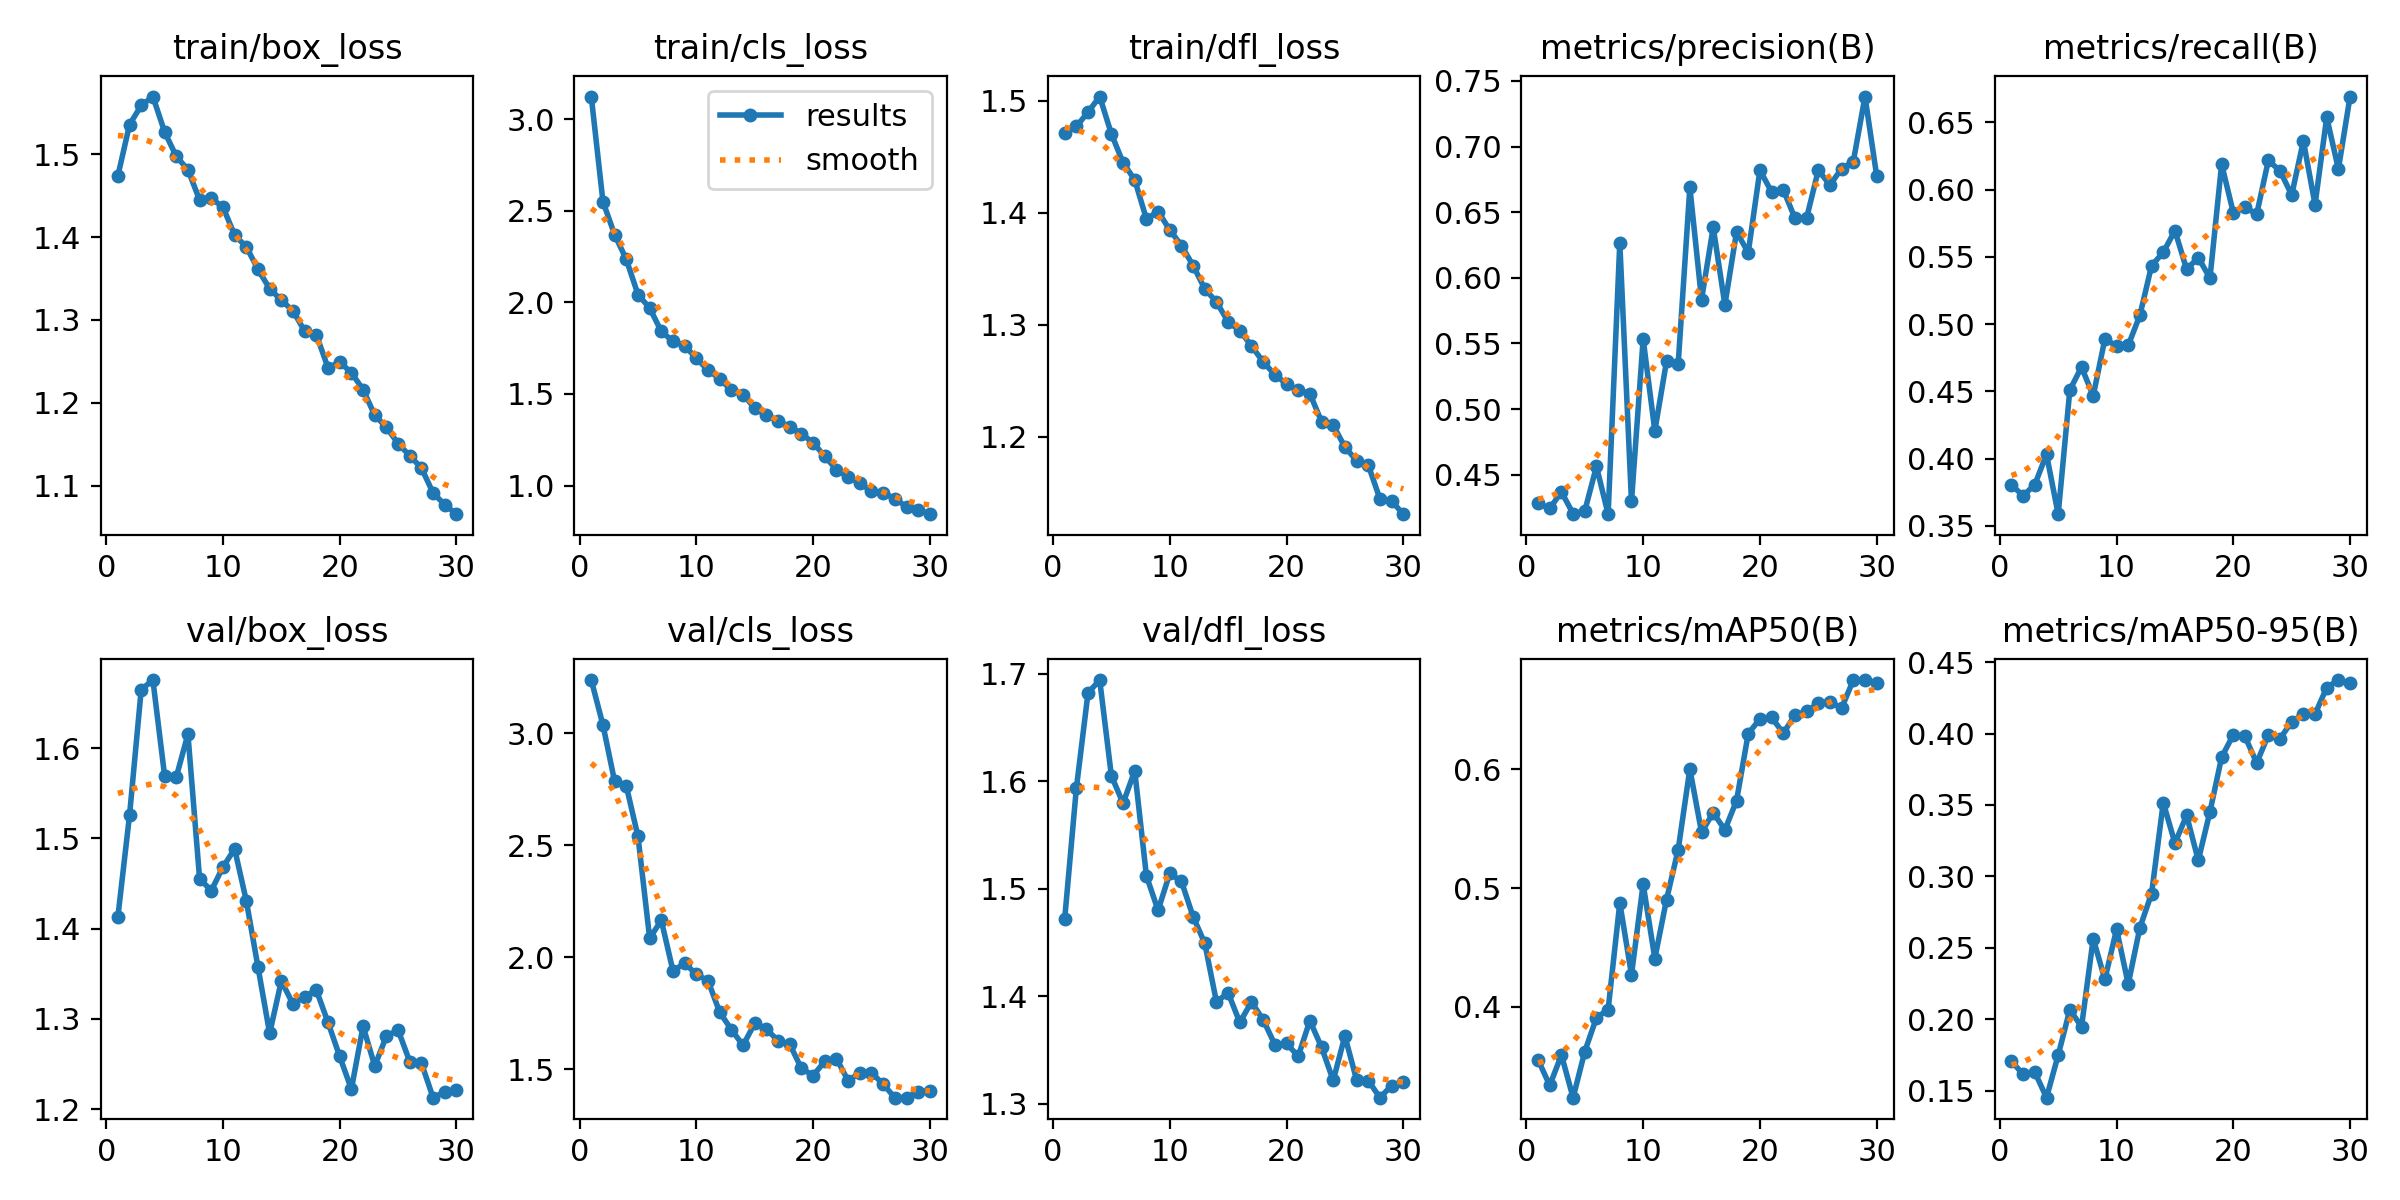

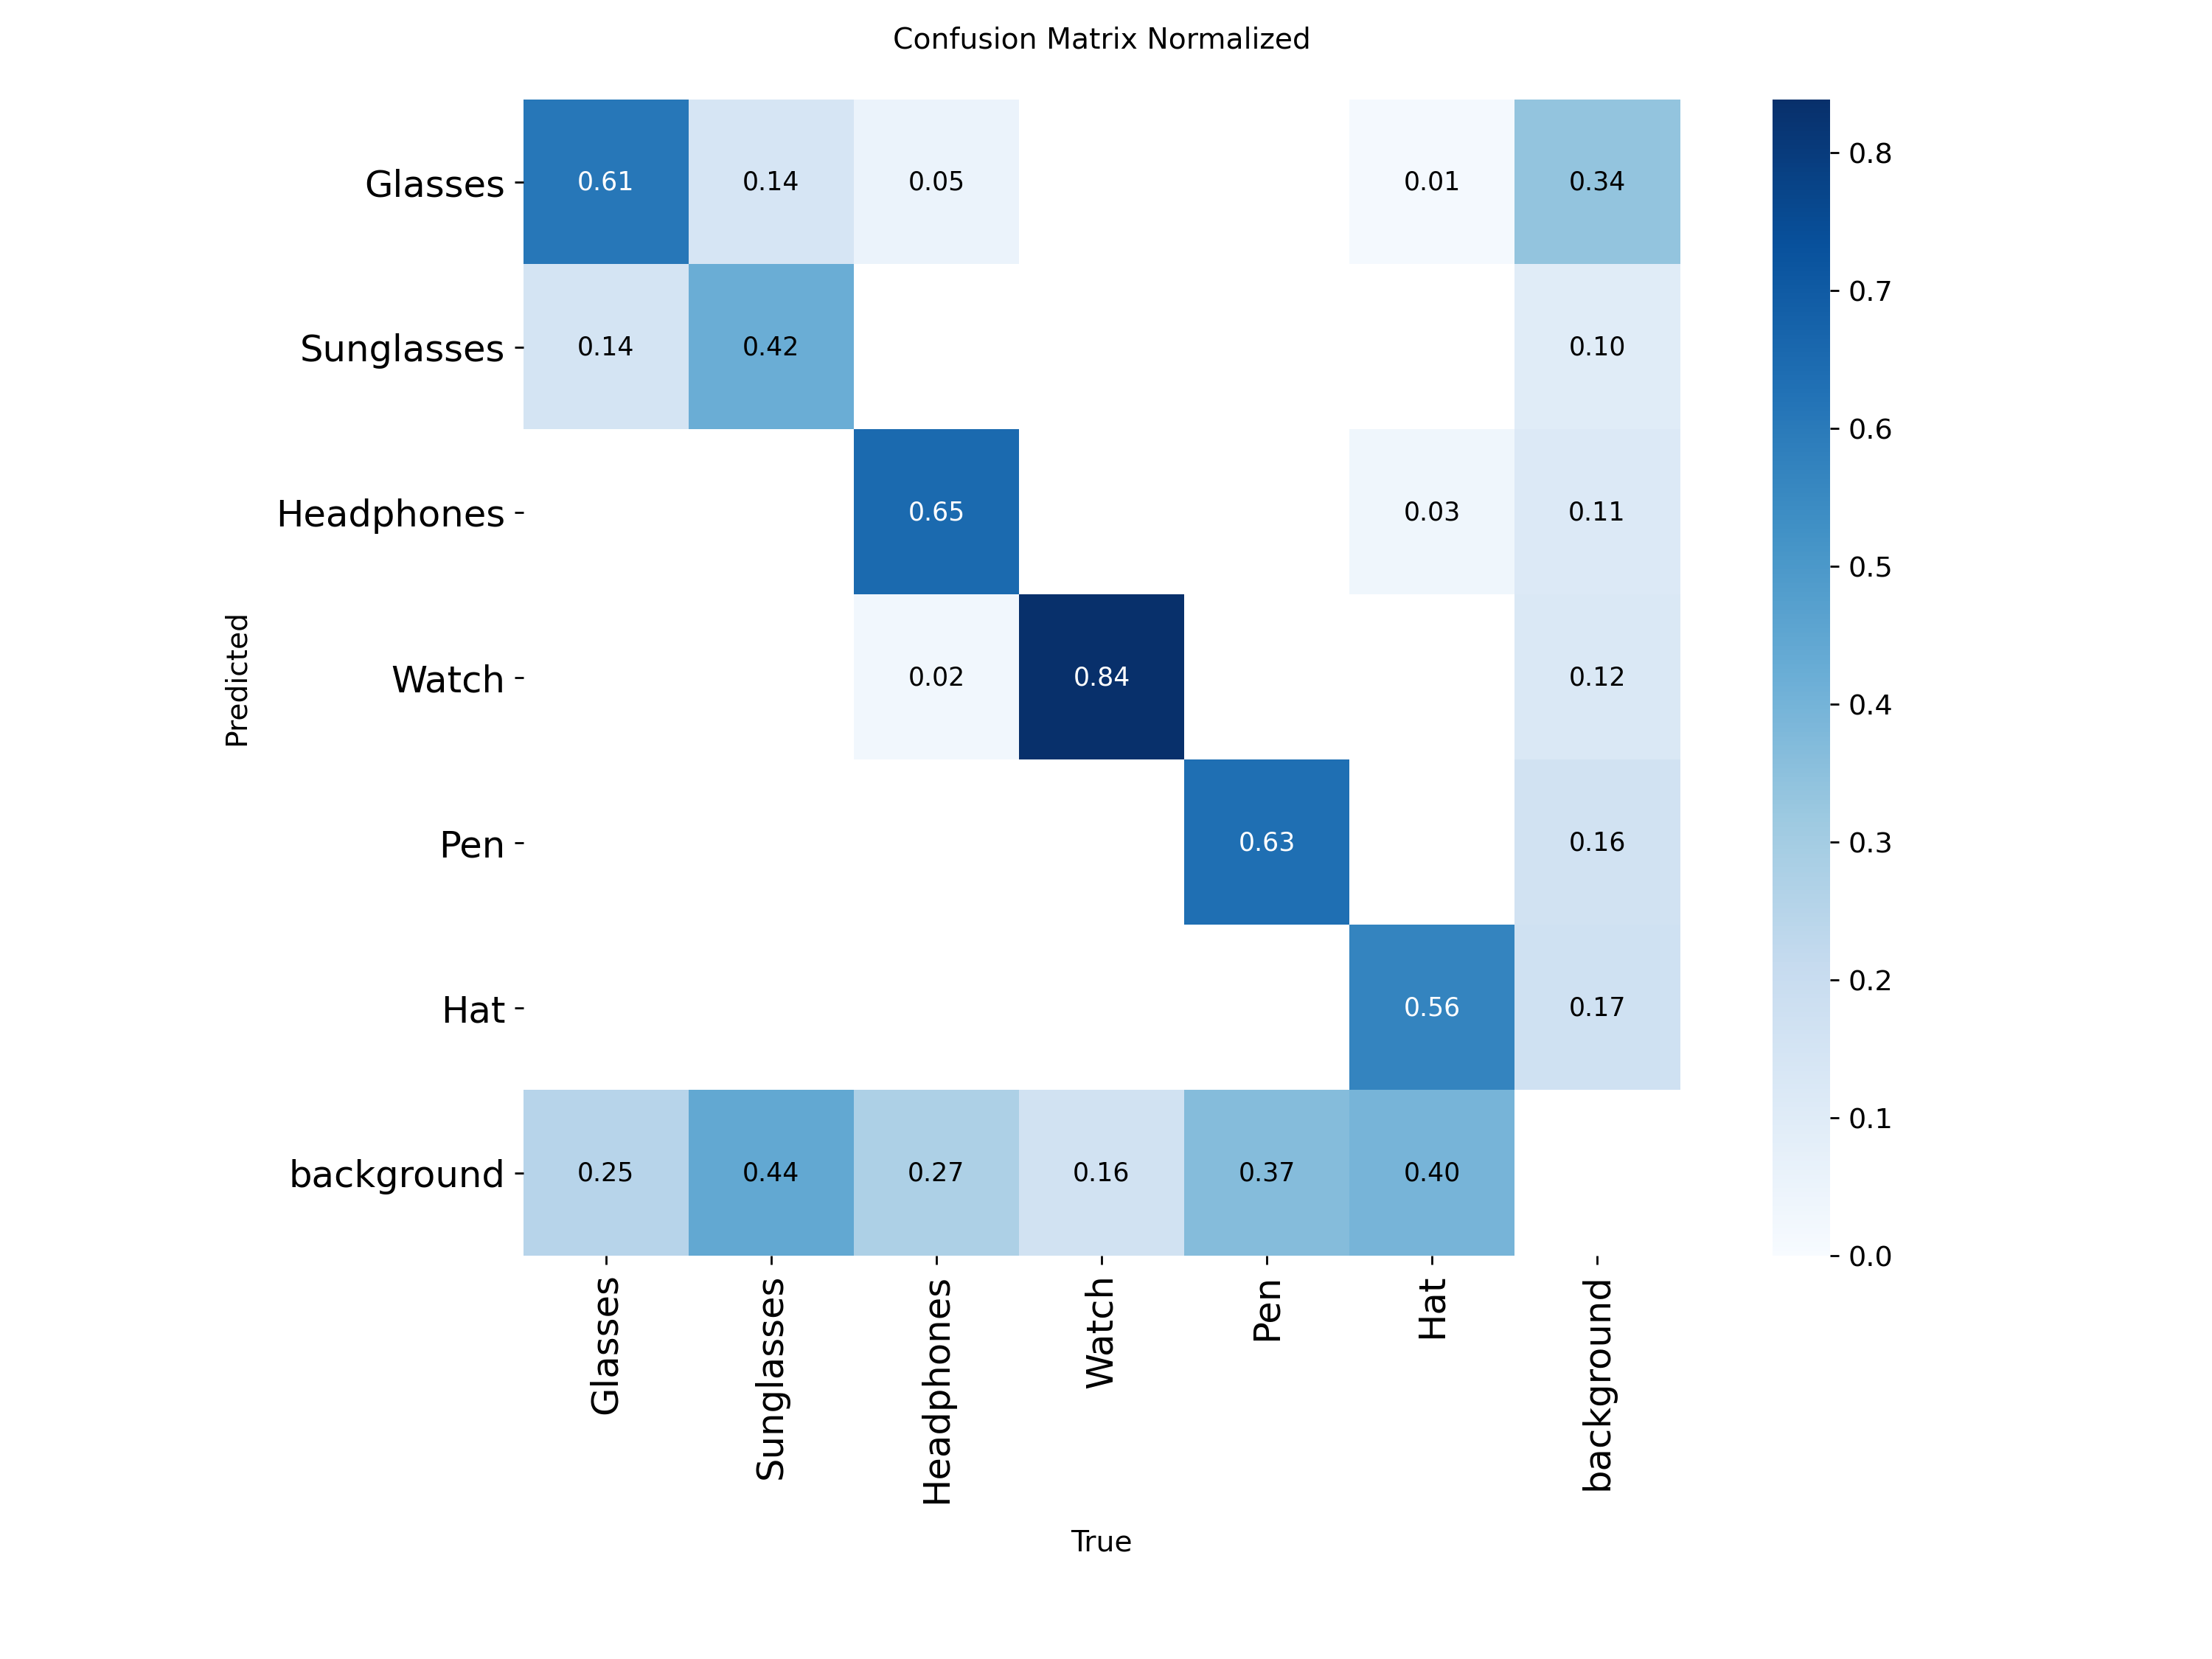

In [5]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv(RESULTS_CSV).set_index("version")
display(df[["mAP50", "mAP50_95", "precision", "recall", "FPS"]])
display(df.filter(like="AP50_").T)

display(Image(f"{PROJECT}/runs/train/v1/results.png", width=900))
display(Image(f"{PROJECT}/runs/val/v1/confusion_matrix_normalized.png", width=650))